# **1. Import Libraries & Load Dataset**

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [183]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Personal/asteroid_project/data/raw/meteorite_landings.csv')

# **2. Initial Data Inspection**

In [184]:
df.head()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


In [185]:
df.tail()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.78333, 8.96667)"
45713,Zlin,30410,Valid,H4,3.3,Found,1939.0,49.25000,17.66667,"(49.25, 17.66667)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.78917, 41.5046)"
45715,Zulu Queen,30414,Valid,L3.7,200.0,Found,1976.0,33.98333,-115.68333,"(33.98333, -115.68333)"


In [186]:
df.shape

(45716, 10)

In [187]:
df.columns

Index(['name', 'id', 'nametype', 'recclass', 'mass (g)', 'fall', 'year',
       'reclat', 'reclong', 'GeoLocation'],
      dtype='object')

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  object 
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  object 
 3   recclass     45716 non-null  object 
 4   mass (g)     45585 non-null  float64
 5   fall         45716 non-null  object 
 6   year         45425 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 3.5+ MB


In [189]:
df.describe().round(3)

,id,mass (g),year,reclat,reclong
count,45716.000,4.558500e+04,45425.000,38401.000,38401.000
mean,26889.735,1.327808e+04,1991.829,-39.123,61.074
std,16860.683,5.749889e+05,25.053,46.379,80.647
min,1.000,0.000000e+00,860.000,-87.367,-165.433
25%,12688.750,7.200000e+00,1987.000,-76.714,0.000
50%,24261.500,3.260000e+01,1998.000,-71.500,35.667
75%,40656.750,2.026000e+02,2003.000,0.000,157.167
max,57458.000,6.000000e+07,2101.000,81.167,354.473


# **3. Cleaning & Filtering**

In [190]:
df.loc[df['year'] > 2025]

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
30682,Northwest Africa 7701,57150,Valid,CK6,55.0,Found,2101.0,0.0,0.0,"(0.0, 0.0)"


In [191]:
df.drop((df.loc[df['year'] > 2025]).index, inplace=True)

In [192]:
df.describe()

,id,mass (g),year,reclat,reclong
count,45715.000000,4.558400e+04,45424.000000,38400.000000,38400.000000
mean,26889.073171,1.327837e+04,1991.826413,-39.123599,61.075909
std,16860.273421,5.749952e+05,25.047805,46.378686,80.647746
min,1.000000,0.000000e+00,860.000000,-87.366670,-165.433330
25%,12688.500000,7.200000e+00,1987.000000,-76.714247,0.000000
50%,24261.000000,3.260000e+01,1998.000000,-71.500000,35.666670
75%,40655.500000,2.026225e+02,2003.000000,0.000000,157.166670
max,57458.000000,6.000000e+07,2013.000000,81.166670,354.473330


In [193]:
for col in df.select_dtypes(include='object').columns:
  if col not in ['name', 'recclass', 'GeoLocation']:
    print(f'{col}: {df[col].unique()}')

nametype: ['Valid' 'Relict']
fall: ['Fell' 'Found']


In [194]:
df.rename(columns={'mass (g)':'mass_g'}, inplace=True)

In [195]:
df.head()

,name,id,nametype,recclass,mass_g,fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


In [196]:
df.duplicated().sum()

np.int64(0)

In [197]:
df.duplicated(subset='name').sum()

np.int64(0)

In [198]:
df.shape

(45715, 10)

In [199]:
df.isna().sum()

,0
name,0
id,0
nametype,0
recclass,0
mass_g,131
fall,0
year,291
reclat,7315
reclong,7315
GeoLocation,7315


In [200]:
df['mass_g'] = df['mass_g'].fillna(0)

In [201]:
df.isna().sum()

,0
name,0
id,0
nametype,0
recclass,0
mass_g,0
fall,0
year,291
reclat,7315
reclong,7315
GeoLocation,7315


In [202]:
print((df == 0).sum())

name              0
id                0
nametype          0
recclass          0
mass_g          150
fall              0
year              0
reclat         6437
reclong        6213
GeoLocation       0
dtype: int64


# **4. Meteorite Type Analysis**

/tmp/ipython-input-3756505505.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




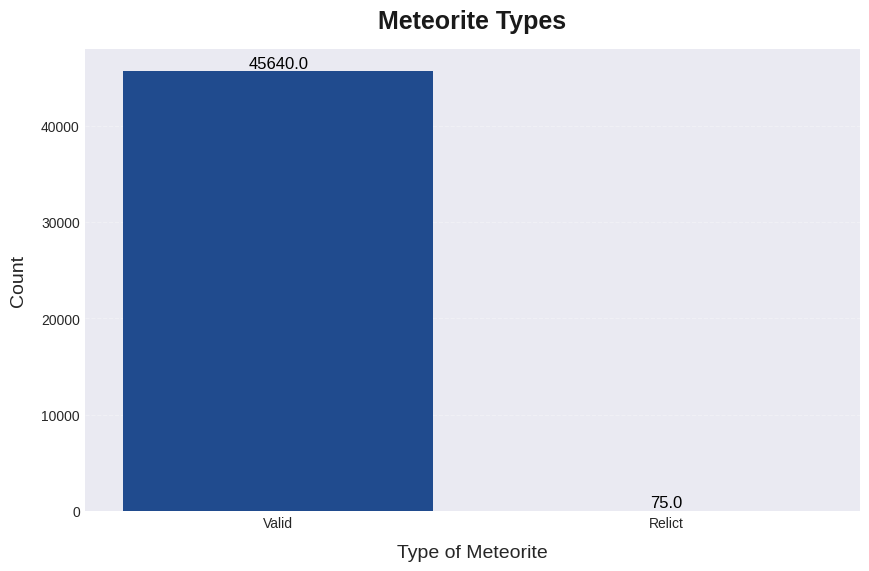

In [203]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='nametype',
    palette=["#0D47A1", "#B71C1C"],
    order=df['nametype'].value_counts().index
)


plt.title(
    "Meteorite Types",
    fontsize=18,
    fontweight='bold',
    color="#1a1a1a",
    pad=15
)


plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlabel("Type of Meteorite", fontsize=14, labelpad=10)
plt.ylabel("Count", fontsize=14, labelpad=10)


for p in plt.gca().patches:
    plt.gca().annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=12,
        color='black'
    )

plt.show()


In [204]:
df = df[~(df['nametype'] == 'Relict')]

In [205]:
df['nametype'].unique()

array(['Valid'], dtype=object)

# **5 Fell vs Found Comparison**

/tmp/ipython-input-2080467469.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




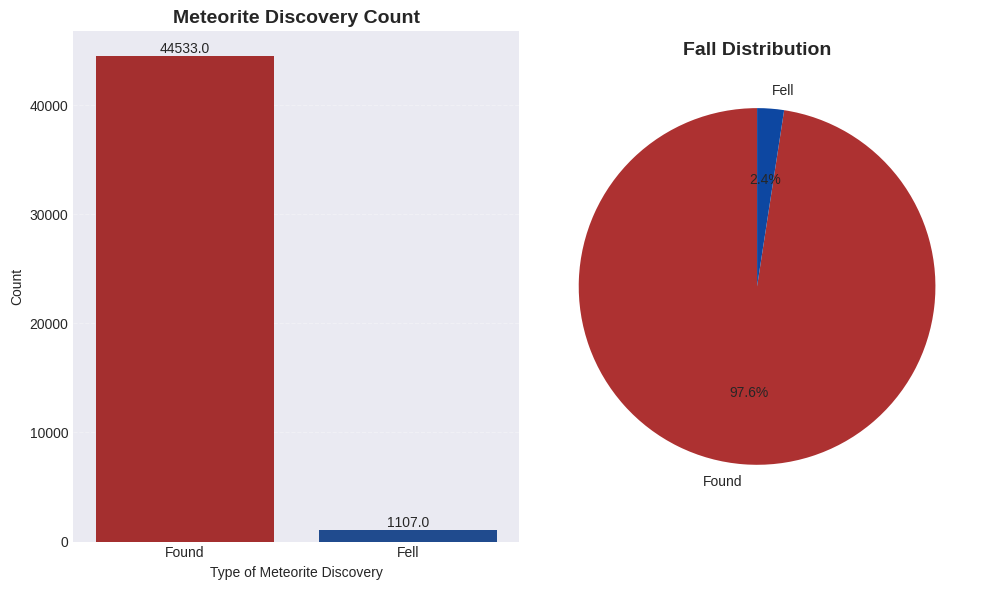

In [206]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))


sns.countplot(
    data=df,
    x='fall',
    palette=["#B71C1C", "#0D47A1"],
    order=df['fall'].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Meteorite Discovery Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Type of Meteorite Discovery")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)


for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height()}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )


axes[1].pie(
    df['fall'].value_counts(),
    labels=df['fall'].value_counts().index,
    colors=["#AD3131", "#0D47A1"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Fall Distribution", fontsize=14, fontweight="bold")




plt.tight_layout()
plt.show()


# **6. Geographic Distribution**

In [207]:
fig = px.density_map(df.loc[df['fall']=='Fell'],
                     lat='reclat',
                     lon='reclong',
                     radius=2.5,
                     color_continuous_scale="inferno",
                     center=dict(lat=34, lon=8), zoom=1,
                     map_style="open-street-map"
                     )


fig.update_traces(opacity=0.7)

fig.update_layout(
    title=dict(
        text="Heatmap of Meteorite Falls (Fall)",
        x=0.5,
        xanchor='center',
        font=dict(size=22, family="Arial, sans-serif", color="black")
    ),
    margin=dict(r=0, t=60, l=0, b=0),
)


fig.show()

In [208]:
fig = px.density_map(df.loc[df['fall']=='Found'],
                     lat='reclat',
                     lon='reclong',
                     radius=1,
                     center=dict(lat=34, lon=8), zoom=1,
                     color_continuous_scale="inferno",
                     map_style="open-street-map"
                     )


fig.update_traces(opacity=0.7)

fig.update_layout(
    title=dict(
        text="Heatmap of Meteorite Falls (Found)",
        x=0.5,
        xanchor='center',
        font=dict(size=22, family="Arial, sans-serif", color="black")
    ),
    margin=dict(r=0, t=60, l=0, b=0),
)


fig.show()

# **7. Meteorite Composition**

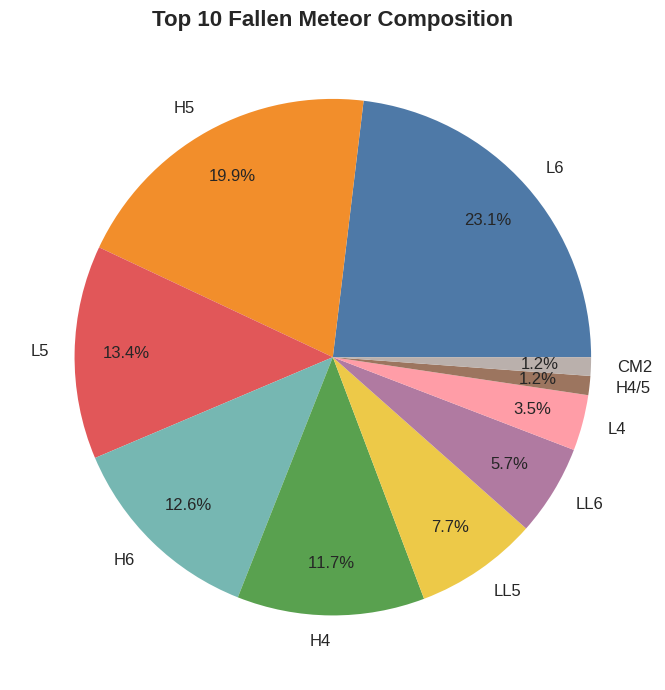

In [209]:
colors = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"
]


plt.figure(figsize=(10,7))
df['recclass'].value_counts()\
                   .head(10)\
                   .plot(kind='pie',
                         autopct='%1.1f%%',
                         colors=colors,
                         pctdistance=0.8,
                         textprops={'fontsize': 12},
                         )

plt.title("Top 10 Fallen Meteor Composition", fontsize=16, weight='bold')
plt.ylabel("")
plt.tight_layout()
plt.show()

# **8. Mass Distribution**

In [210]:
fig = px.scatter_geo(df,
                     lat='reclat',
                     lon='reclong',
                     color='recclass',
                     hover_name="name",
                     size="mass_g",
                     projection="natural earth"
                     )


fig.update_traces(opacity=0.7)

fig.update_layout(
    title=dict(
        text="Map of Meteorite Landings Based on Their Mass & Composition",
        x=0.5,
        xanchor='center',
        font=dict(size=22, family="Arial, sans-serif", color="black")
    ),
    margin=dict(r=0, t=60, l=0, b=0),
)


fig.show()

/tmp/ipython-input-2159790652.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2159790652.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




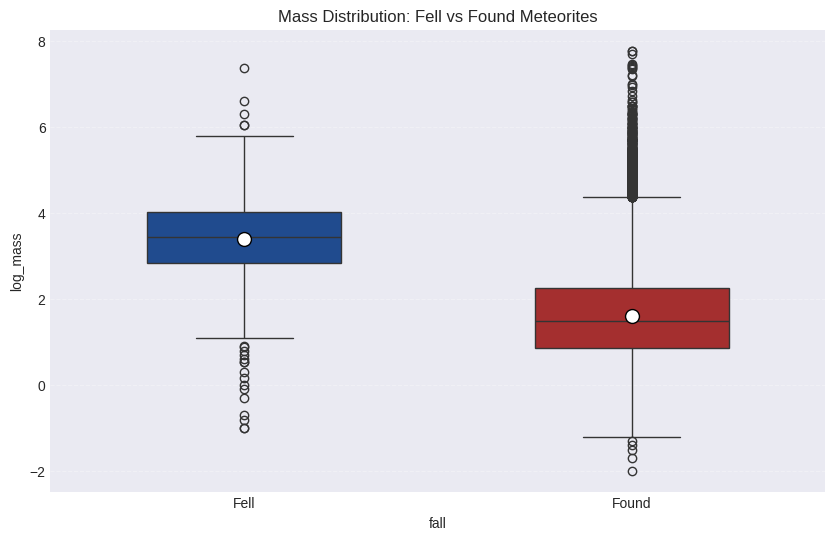

In [211]:
df_plot = df.loc[df['mass_g'] != 0]
df_plot['log_mass'] = np.log10(df_plot['mass_g'])

plt.figure(figsize=(10,6))
sns.boxplot(data=df_plot,
            x='fall',
            y='log_mass',
            palette=["#0D47A1", "#B71C1C"],
            width=0.5,
            showmeans=True,
            meanprops={
                        "marker": "o",
                        "markerfacecolor": "white",
                        "markeredgecolor": "black",
                        "markersize": 10
                       }
            )

plt.title("Mass Distribution: Fell vs Found Meteorites")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [212]:
df.sort_values(by='mass_g', ascending=False).head(1)

,name,id,nametype,recclass,mass_g,fall,year,reclat,reclong,GeoLocation
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,1920.0,-19.58333,17.91667,"(-19.58333, 17.91667)"


In [213]:
fig = px.scatter_geo(df.sort_values(by='mass_g', ascending=False).head(1),
                     lat='reclat',
                     lon='reclong',
                     color='recclass',
                     hover_name="name",
                     hover_data=['fall'],
                     size="mass_g",
                     projection="natural earth"
                     )


fig.update_traces(opacity=0.7)

fig.update_layout(
    title=dict(
        text="Location of the Largest Meteor by Mass",
        x=0.5,
        xanchor='center',
        font=dict(size=22, family="Arial, sans-serif", color="black")
    ),
    margin=dict(r=0, t=60, l=0, b=0),
)


fig.show()


In [214]:
df.loc[df['mass_g'] != 0].sort_values(by='mass_g').head(1)

,name,id,nametype,recclass,mass_g,fall,year,reclat,reclong,GeoLocation
42703,Yamato 8333,29438,Valid,H5,0.01,Found,1983.0,-71.5,35.66667,"(-71.5, 35.66667)"


In [215]:
fig = px.scatter_geo(df.loc[df['mass_g'] != 0].sort_values(by='mass_g').head(1),
                     lat='reclat',
                     lon='reclong',
                     color='recclass',
                     hover_name="name",
                     hover_data=['fall'],
                     size="mass_g",
                     projection="natural earth"
                     )

fig.update_traces(opacity=0.7)

fig.update_layout(
    title=dict(
        text="Location of the Smallest Meteor by Mass",
        x=0.5,
        xanchor='center',
        font=dict(size=22, family="Arial, sans-serif", color="black")
    ),
    margin=dict(r=0, t=60, l=0, b=0),
)


fig.show()

# **9. Temporal Analysis**

/tmp/ipython-input-3126678775.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




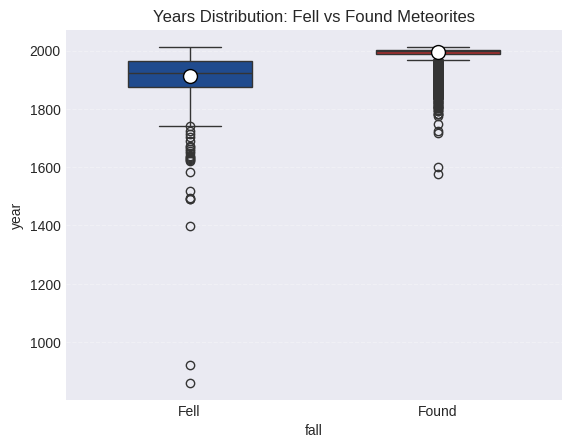

In [216]:
sns.boxplot(df,
            x='fall',
            y='year',
            palette=["#0D47A1", "#B71C1C"],
            width=0.5,
            showmeans=True,
            meanprops={
                        "marker": "o",
                        "markerfacecolor": "white",
                        "markeredgecolor": "black",
                        "markersize": 10
                       }
            )

plt.title("Years Distribution: Fell vs Found Meteorites")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

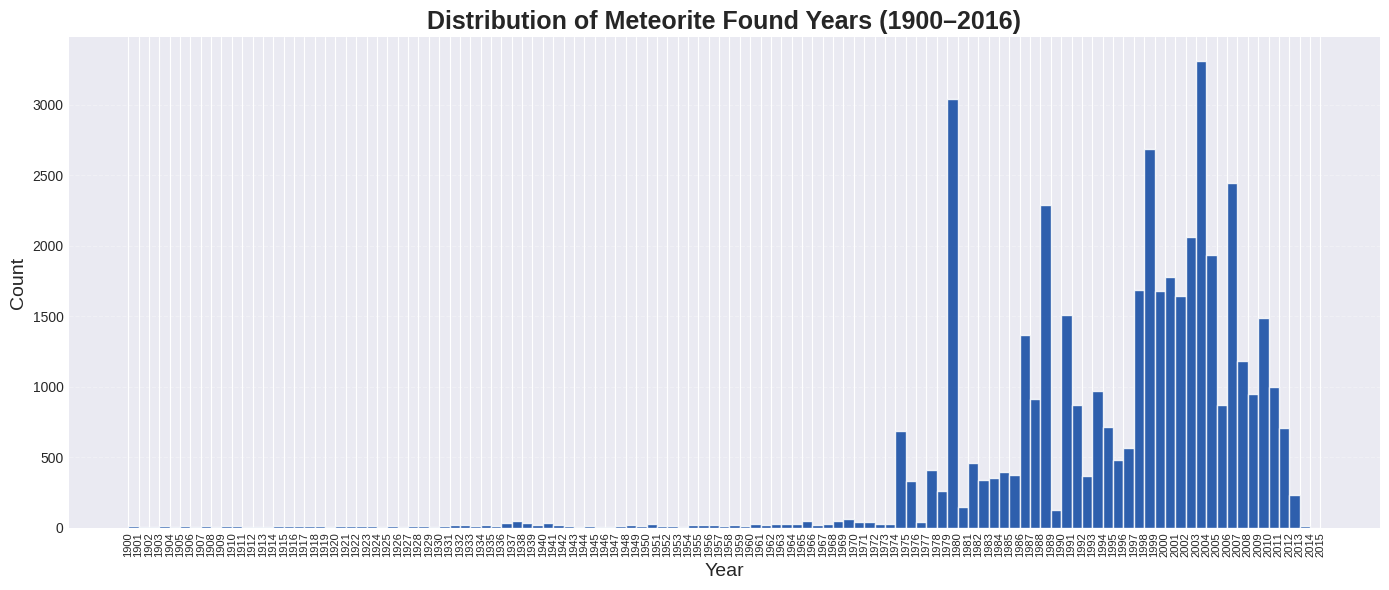

In [217]:
values = df.loc[df['fall'] == 'Found']['year'].dropna()

plt.figure(figsize=(14,6))

plt.hist(values,
         bins=np.arange(1900, 2016, 1),
         color="#0D47A1",
         edgecolor="white",
         alpha=0.85)

plt.title("Distribution of Meteorite Found Years (1900–2016)",
          fontsize=18, fontweight="bold")

plt.xlabel("Year", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(np.arange(1900, 2016, 1), rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()




plt.show()


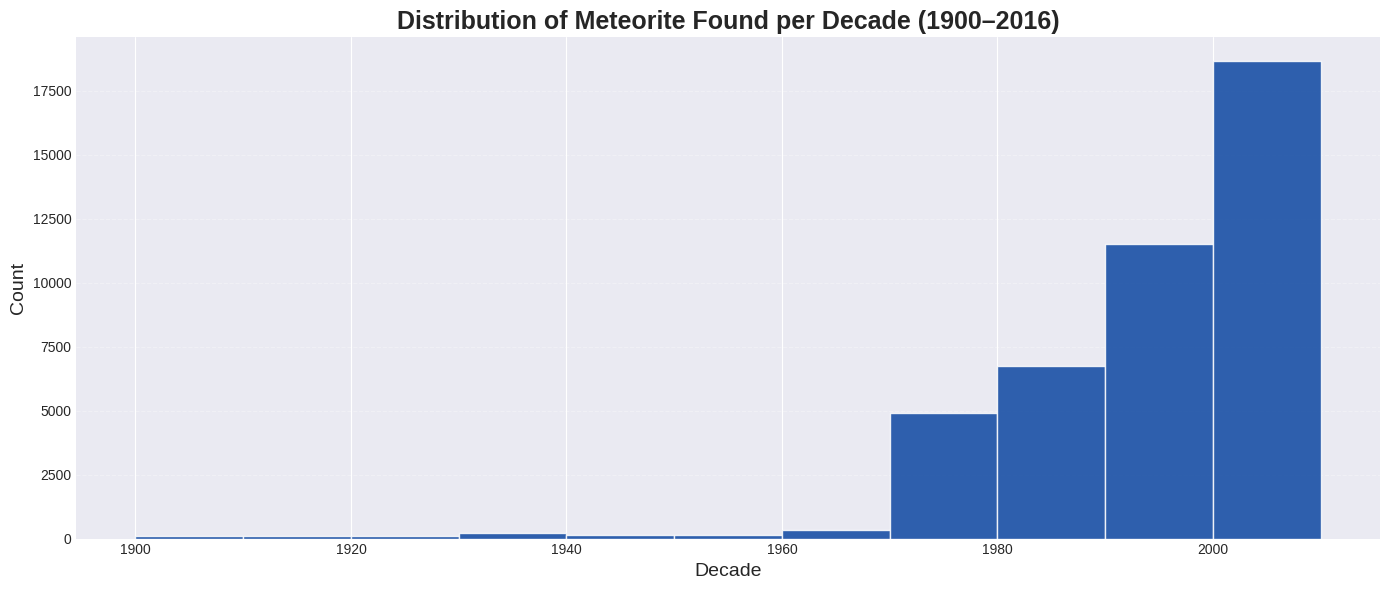

In [225]:
values = df.loc[df['fall'] == 'Found']['year'].dropna()

plt.figure(figsize=(14,6))

plt.hist(values,
         bins=np.arange(1900, 2016, 10),
         color="#0D47A1",
         edgecolor="white",
         alpha=0.85)

plt.title("Distribution of Meteorite Found per Decade (1900–2016)",
          fontsize=18, fontweight="bold")

plt.xlabel("Decade", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()




plt.show()


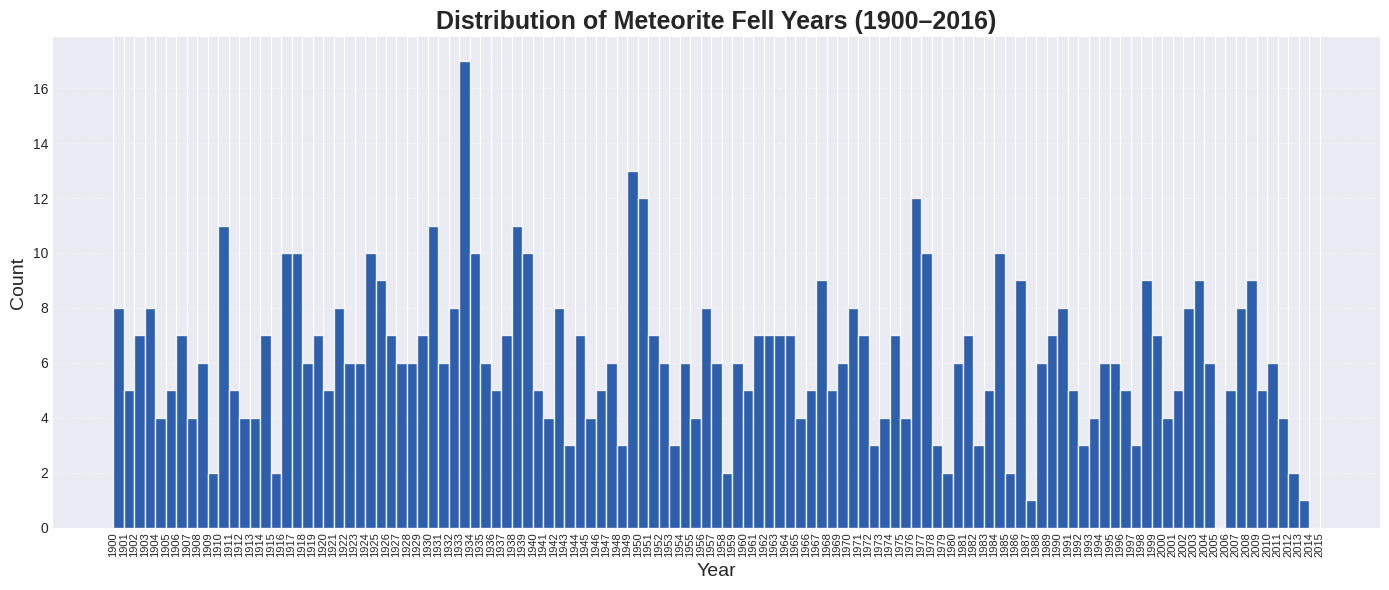

In [219]:
values = df.loc[df['fall'] == 'Fell']['year'].dropna()

plt.figure(figsize=(14,6))

plt.hist(values,
         bins=np.arange(1900, 2016, 1),
         color="#0D47A1",
         edgecolor="white",
         alpha=0.85)

plt.title("Distribution of Meteorite Fell Years (1900–2016)",
          fontsize=18, fontweight="bold")

plt.xlabel("Year", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(np.arange(1900, 2016, 1), rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()




plt.show()


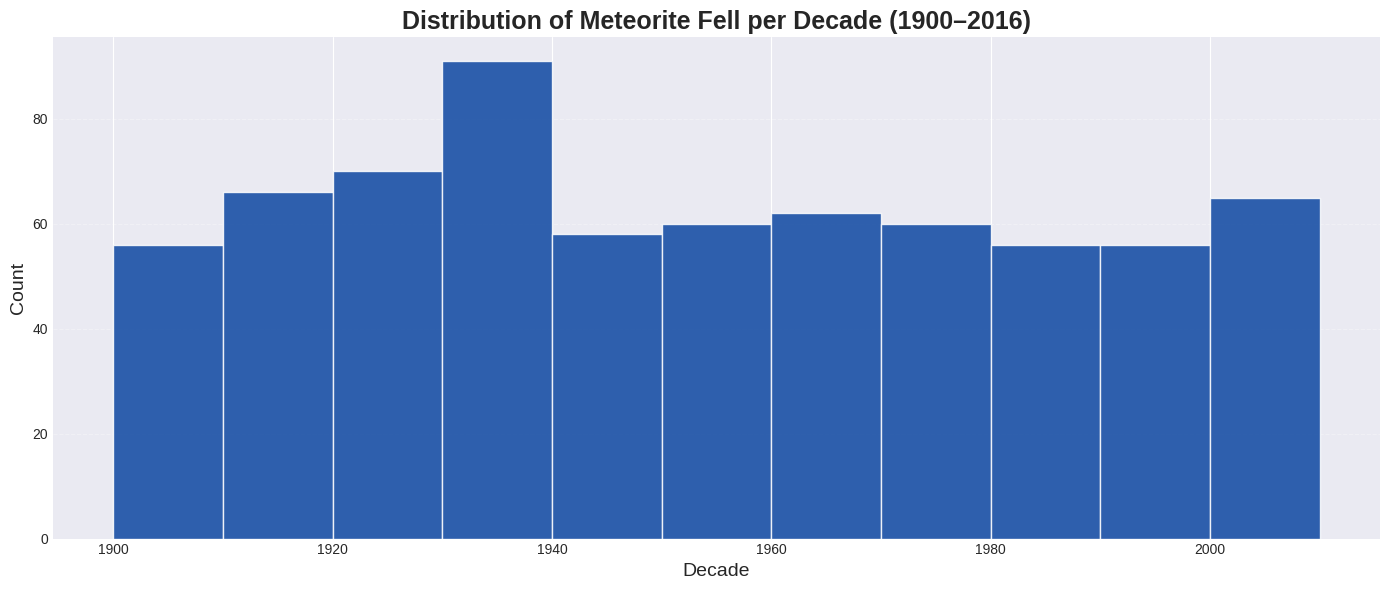

In [224]:
values = df.loc[df['fall'] == 'Fell']['year'].dropna()

plt.figure(figsize=(14,6))

plt.hist(values,
         bins=np.arange(1900, 2016, 10),
         color="#0D47A1",
         edgecolor="white",
         alpha=0.85)

plt.title("Distribution of Meteorite Fell per Decade (1900–2016)",
          fontsize=18, fontweight="bold")

plt.xlabel("Decade", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()


# **10. Final Cleanup & Data Quality Check**

In [221]:
df.drop(['id', 'GeoLocation', 'name', 'nametype'], axis=1, inplace=True)

In [222]:
df.loc[(df['reclat']==0) & (df['reclong']==0)].shape[0]/df.shape[0]

0.13613058720420684

In [223]:
df[~((df['reclat']==0) & (df['reclong']==0))]

,recclass,mass_g,fall,year,reclat,reclong
0,L5,21.0,Fell,1880.0,50.77500,6.08333
1,H6,720.0,Fell,1951.0,56.18333,10.23333
2,EH4,107000.0,Fell,1952.0,54.21667,-113.00000
3,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000
4,L6,780.0,Fell,1902.0,-33.16667,-64.95000
...,...,...,...,...,...,...
45711,Eucrite,172.0,Found,1990.0,29.03700,17.01850
45712,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667
45713,H4,3.3,Found,1939.0,49.25000,17.66667
45714,L6,2167.0,Found,2003.0,49.78917,41.50460
